#  GenAI-101 - Introduction

<!-- > **"A compelling quote or key idea that frames the lesson."**
> — Ismail Hamdaoui / Paper -->

# Preface

It is needless to remind that all AI-algorithms, are grounded in mathematics — most commonly in some 
combination of calculus, linear algebra, and probability theory.

Take least squares as a familiar example: the algorithm solves an 
optimization problem, minimizing the sum of squared residuals — the 
distances between data points and a candidate line — to find the best 
linear approximation. The objective is clear, the solution is closed-form, 
and the output is always deterministic: one line.

But generative AI asks a fundamentally different question.

---

# I. What Does a Generative Model Need to Do?

Let's be concrete. Suppose we want a model that generates images of animals.
For such a model to be useful, it must satisfy at least two requirements:

1. **Coverage** — it must be capable of generating many different 
   categories: dogs, cats, horses, and so on.
2. **Diversity within categories** — when asked for a cat, it should 
   produce a different cat each time: different poses, colors, backgrounds.

These two requirements immediately rule out deterministic functions.
A deterministic function maps each input to exactly one output — run it 
twice with the same input, get the same result. It has no mechanism for 
variability. Even if we feed it random noise as input, it still can't 
capture the *structure* of what makes a valid cat image versus a valid 
dog image — it has no model of the data.

What we need is a mathematical object that natively represents 
**uncertainty and variability**. That object is a **random variable**.

![Architecture diagram](docs/intro/func.png)
---

# II. Random Variables and Probability Distributions

A random variable $X$ is not simply "a different kind of function." 
Formally, it is a measurable function defined on a probability space — 
but what makes it powerful is that it carries a **probability distribution** 
$p(X)$ that governs how likely each outcome is.

Once we have a distribution, we can **sample** from it: draw a value 
according to its probabilities, get a different result each time, and 
yet have every result be consistent with the same underlying structure.

A Gaussian distribution, for instance, always produces numbers 
concentrated around its mean, with the spread controlled by its variance. 
Run it a thousand times — no two outputs are identical, yet all of them 
are statistically coherent.

> **Key shift:** We move from asking *"what is the output?"* to asking 
> *"what is the distribution of outputs?"*

---

# III. Problem Formulation

A generative model's job is to **approximate an unknown data distribution**.

More precisely: we observe samples (images, text, audio) drawn from some 
true distribution $p_{data}$ that we cannot access directly. We want to 
learn a parametric distribution $p_\theta$ — controlled by parameters 
$\theta$ — such that $p_\theta \approx p_{data}$. Once we have that, 
we can sample from $p_\theta$ to generate new, realistic data.

Returning to our image example: generating 32×32 images means modeling 
a joint probability distribution over $\mathbb{R}^{32 \times 32}$ — 
a space of 1,024 dimensions. The challenge is not just the dimensionality 
itself, but the fact that **realistic images occupy an extremely small 
region of that space**. A random vector in $\mathbb{R}^{1024}$ looks 
like noise. A real dog image obeys thousands of implicit structural 
constraints — pixel continuity, object shapes, lighting coherence — and 
the distribution must encode all of them.

This is what makes generative modeling hard.

### Modes

In a probability distribution, a **mode** is a region of high probability 
mass — a cluster of likely outputs. In our animal example, "cats" and 
"dogs" would each be a separate mode. A distribution with multiple modes 
is called **multimodal**.

Generating a specific category = sampling from a specific mode.  
This concept will become critical when we study models that struggle 
with **mode collapse** — producing only one type of output and ignoring 
the rest.

---

# IV. Distribution Estimation — A Grounded Example

Before tackling image generation, let's build intuition with a simpler 
case: a population of 2D points.

We observe a finite set of points in the plane. We don't know the 
distribution that generated them — but we want to learn it well enough 
to generate new points that are statistically indistinguishable from the 
originals.

This is **density estimation**, and it is the core problem every 
generative model solves — whether it's a VAE learning a latent space, 
a GAN playing an adversarial game, or a diffusion model learning to 
reverse noise.

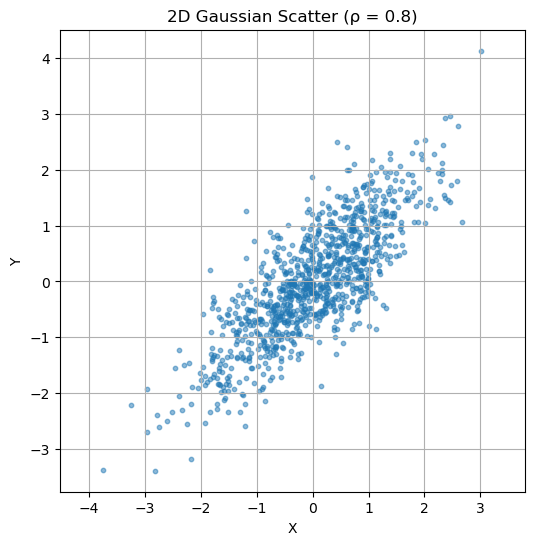

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Mean
mean = [0, 0]

# Standard deviations
sigma_x = 1
sigma_y = 1

# Correlation coefficient
rho = 0.8

# Correlation matrix
corr_matrix = np.array([
    [1, rho],
    [rho, 1]
])

# Convert to covariance matrix
std_matrix = np.array([
    [sigma_x, 0],
    [0, sigma_y]
])

cov_matrix = std_matrix @ corr_matrix @ std_matrix

# Generate points
n = 1000
data = np.random.multivariate_normal(mean, cov_matrix, n)
x, y = data[:, 0], data[:, 1]

# Plot (same clean style as before)
plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.5, s=10)

plt.title(f"2D Gaussian Scatter (ρ = {rho})")
plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)

plt.show()

Looking at the graph we can make tremendous assumptions : 
- we notice first that we must find a probability distribution over the 2D space $\R^{2}$. 
- since points are scattered in a symmetrical way over the central point called the mean (to be found later) meaning skewness, or third moment = 0, meaking gaussian assumption is valid here.
- Now we are left to find these gaussian parameters, a 2D gaussian is defined by : 
the mean **Mean** $\mu$, the central point in the graph above, and the Correlation-Matrix $\sigma$ that describes how points are scattered in each direction :

- Thankfully, we have formulas in statistics that helps us estimate them through the empirical values we have above following :  
$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i

\space\space\space\space\space || \space\space\space\space\space

\hat{\Sigma} = \frac{1}{n} \sum_{i=1}^{n} (\mathbf{x}_i - \hat{\mu})(\mathbf{x}_i - \hat{\mu})^\top $$



> 💡**Insight** : *in statistics, we write the variable with a hat above $\hat{\mu}$ instead of $\mu$ to signify it is just an approximation to our best, since the true value is still hidden, unkonwn.*

In [4]:
import numpy as np

# data = your (n,2) array
mu = np.mean(data, axis=0)
cov = np.cov(data.T)

print("Estimated mean:", mu)
print("Estimated covariance:\n", cov)

Estimated mean: [ 0.02332448 -0.00313353]
Estimated covariance:
 [[1.01597497 0.83088271]
 [0.83088271 1.05782522]]


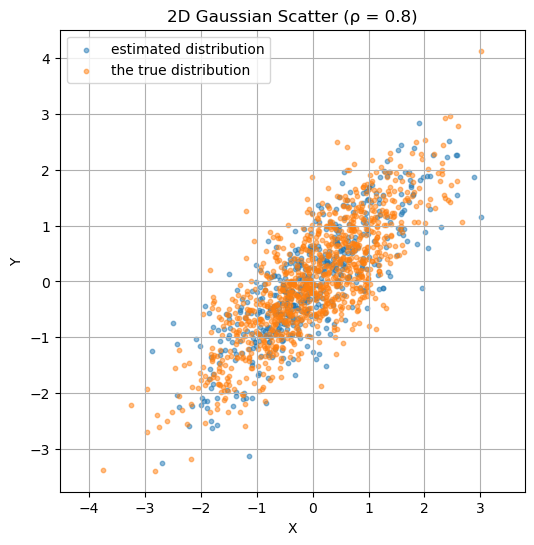

In [7]:
# Estimated Mean
mean_hat = [ 0.02332448,-0.00313353]


# Estimated Correlation matrix
cov_matrix_hat = np.array( [[1.01597497,0.83088271],[0.83088271,1.05782522]])


# Generate points
n = 500
data_new = np.random.multivariate_normal(mean_hat, cov_matrix_hat, n)
x_new, y_new = data_new[:, 0], data_new[:, 1]

# Plot (same clean style as before)
plt.figure(figsize=(6,6))
plt.scatter(x_new, y_new, alpha=0.5, s=10, label="estimated distribution")
plt.scatter(x, y, alpha=0.5, s=10, label="the true distribution")

plt.title(f"2D Gaussian Scatter (ρ = {rho})")
plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# 🧩 Exercise :
> find the underlying distribution for this underlying points cloud.

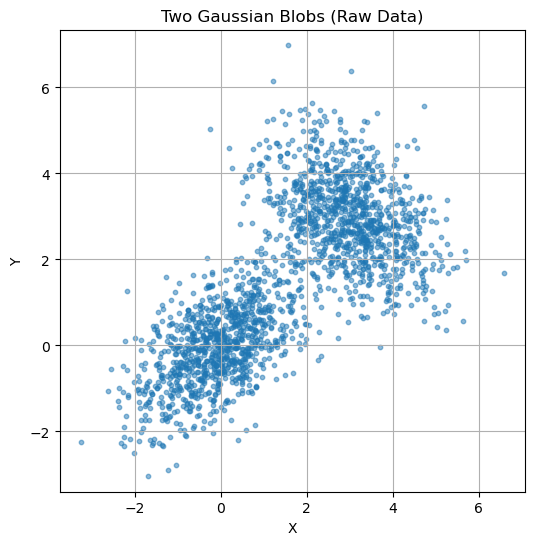

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ----------------------------
# 1. Generate two Gaussian blobs
# ----------------------------
np.random.seed(42)

n = 1000

# Blob 1
mean1 = [0, 0]
cov1 = [[1, 0.6],
        [0.6, 1]]
data1 = np.random.multivariate_normal(mean1, cov1, n)

# Blob 2
mean2 = [3, 3]
cov2 = [[1, -0.4],
        [-0.4, 1]]
data2 = np.random.multivariate_normal(mean2, cov2, n)

# Combine data
data = np.vstack([data1, data2])

# ----------------------------
# 2. Plot raw data
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.5)
plt.title("Two Gaussian Blobs (Raw Data)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()



In [13]:

# ----------------------------
# 3. Fit Gaussian Mixture Model
# ----------------------------
gmm = GaussianMixture(n_components=2, random_state=42)
print(gmm)
gmm.fit(data)


# ----------------------------
# 4. Function to draw ellipses
# ----------------------------
def draw_ellipse(position, covariance, ax, **kwargs):
    from matplotlib.patches import Ellipse
    import numpy.linalg as la

    # Eigen decomposition
    vals, vecs = la.eigh(covariance)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Compute angle
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height (2 std dev)
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(xy=position, width=width, height=height,
                      angle=theta, fill=False, **kwargs)
    ax.add_patch(ellipse)


# ----------------------------
# 5. Plot GMM approximation
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.3)

ax = plt.gca()

# Plot each Gaussian component
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, edgecolor='red', linewidth=2)

plt.title("GMM Approximation (2 Components)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()

GaussianMixture(n_components=2, random_state=42)


AttributeError: 'NoneType' object has no attribute 'split'